IMPORTING LIBRARIES

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

TEST IMAGE PROCESSING

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'C:\\Users\\s\\Desktop\\Data science\\PLANT PROJECT\\New Plant Diseases Dataset(Augmented)\\valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

LOADING MODEL

In [5]:
cnn = tf.keras.models.load_model('C:\\Users\\s\\Desktop\\Data science\\PLANT PROJECT\\trained_plant_disease_model.keras')

VISUALISING AND PERFORMING PREDICTION

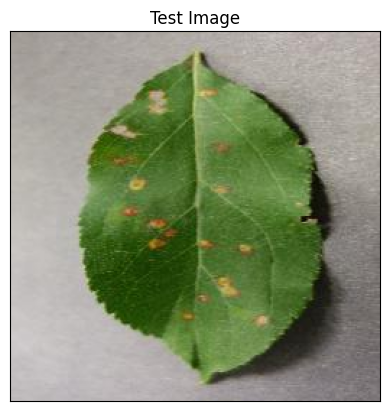

In [6]:
#Test Image Visualization
import cv2
image_path = 'C:\\Users\\s\\Desktop\\Data science\\PLANT PROJECT\\New Plant Diseases Dataset(Augmented)\\valid\\Apple___Cedar_apple_rust\\0cd24b0c-0a9d-483f-8734-5c08988e029f___FREC_C.Rust 3762_180deg.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

TESTING MODEL

In [7]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step


In [8]:
print(predictions)

[[7.76705988e-08 2.51889628e-06 9.99892592e-01 7.71345765e-11
  7.29138492e-08 2.25471397e-09 1.99085637e-09 3.04149483e-09
  6.02500601e-12 6.06775430e-09 8.06181768e-14 2.78389143e-06
  1.74189676e-08 3.77092801e-12 7.25738469e-10 7.57192311e-07
  2.94691490e-05 5.24897792e-10 6.11450523e-05 1.42068846e-09
  1.25304089e-09 2.24955499e-09 4.11469275e-10 1.00505389e-10
  1.19226721e-12 4.27258099e-12 3.66691538e-10 5.24043239e-11
  1.42591659e-06 1.15169534e-07 1.43050172e-09 2.78783112e-08
  8.71907469e-06 4.46564313e-12 2.90981660e-07 6.08555484e-10
  1.61681293e-11 1.98625824e-10]]


In [9]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


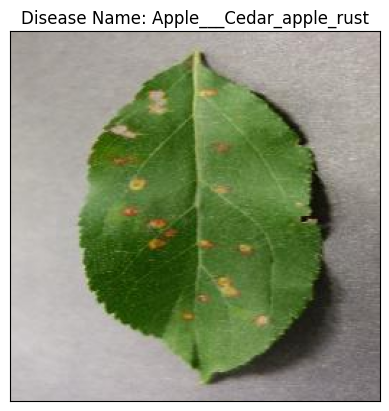

In [10]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()